<a href="https://colab.research.google.com/github/jjyjung/ai_semicon/blob/main/src/cnn/tf_keras_CNN_augment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')   # google drive를 google colab에 연결. 처음 실행 시, 인증 필요

dir = "/content/drive/MyDrive/Colab Notebooks/ai/"  ### [중요!!] Colab의 경우, 저장할 위치를 기록하시오.

Mounted at /content/gdrive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


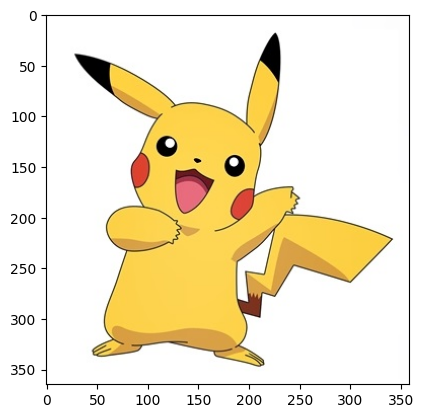

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# 이미지 파일 경로 설정
image_path = dir+'pokemon.jpg'

# 이미지 열기
image = Image.open(image_path)

# 이미지 표시
plt.imshow(image)
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#augmentation이 적용된 image들을 시각화 해주는 함수
def show_aug_image(image, generator, n_images=4):

    # ImageDataGenerator는 여러개의 image를 입력으로 받기 때문에 4차원으로 입력 해야함.
    image_batch = np.expand_dims(image, axis=0)

    # featurewise_center or featurewise_std_normalization or zca_whitening 가 True일때만 fit 해주어야함
    generator.fit(image_batch)
    # flow로 image batch를 generator에 넣어주어야함.
    data_gen_iter = generator.flow(image_batch)

    fig, axs = plt.subplots(nrows=1, ncols=n_images, figsize=(24, 8))

    for i in range(n_images):
    	#generator에 batch size 만큼 augmentation 적용(매번 적용이 다름)
        aug_image_batch = next(data_gen_iter)
        aug_image = np.squeeze(aug_image_batch)
        aug_image = aug_image.astype('int')
        axs[i].imshow(aug_image)

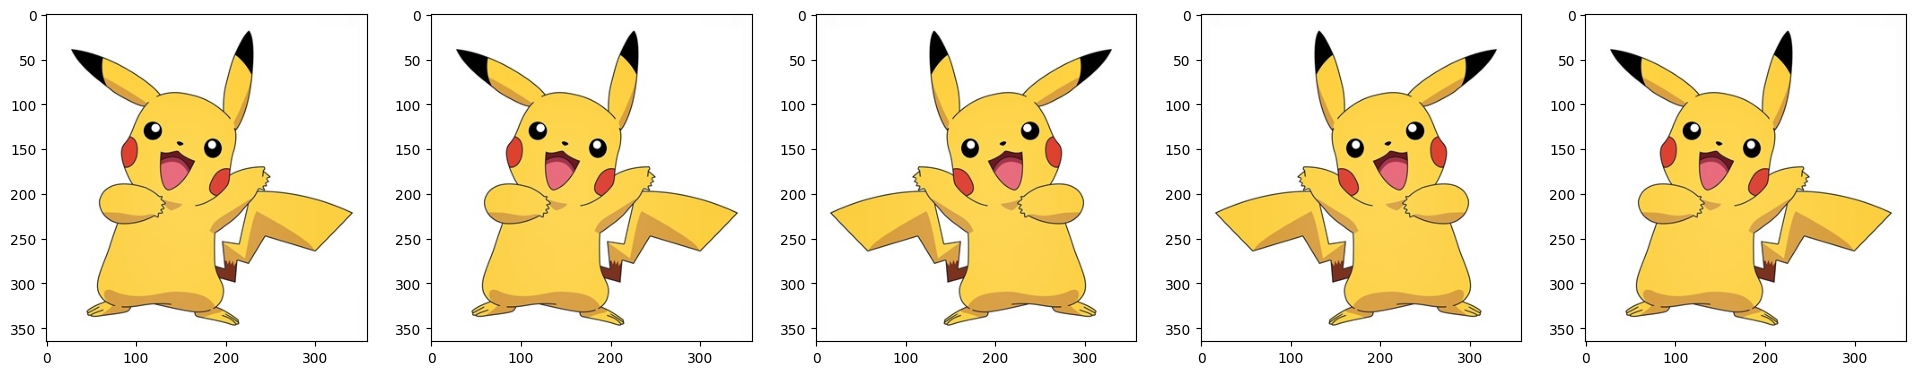

In [ ]:
data_generator = ImageDataGenerator(horizontal_flip=True)
show_aug_image(image, data_generator, n_images=5)

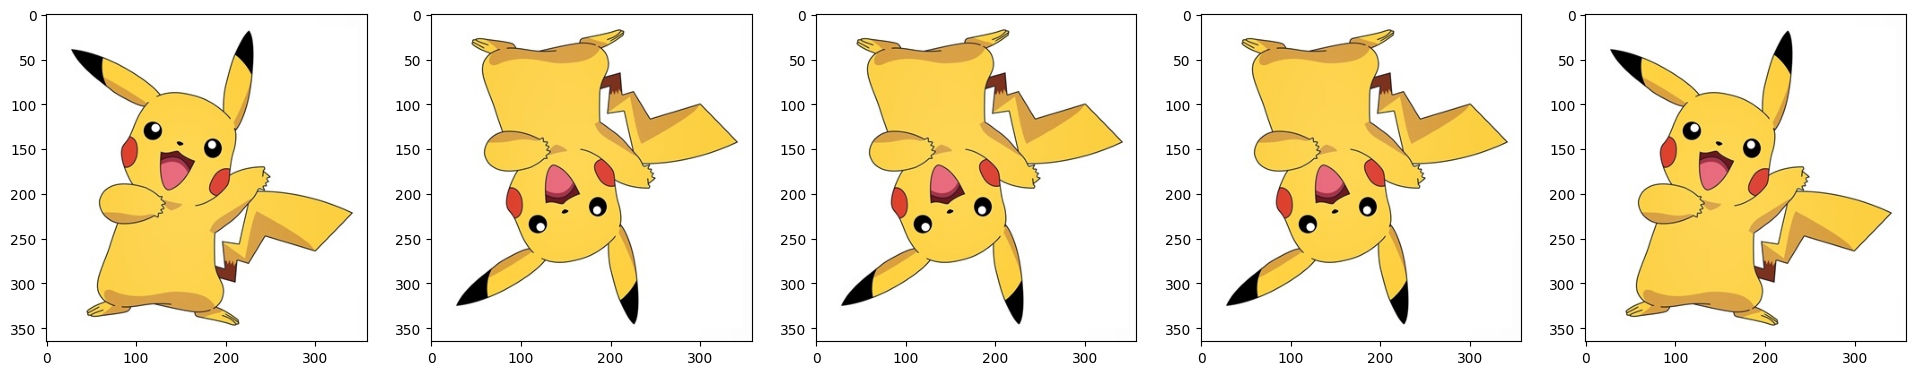

In [ ]:
data_generator = ImageDataGenerator(vertical_flip=True)
show_aug_image(image, data_generator, n_images=5)

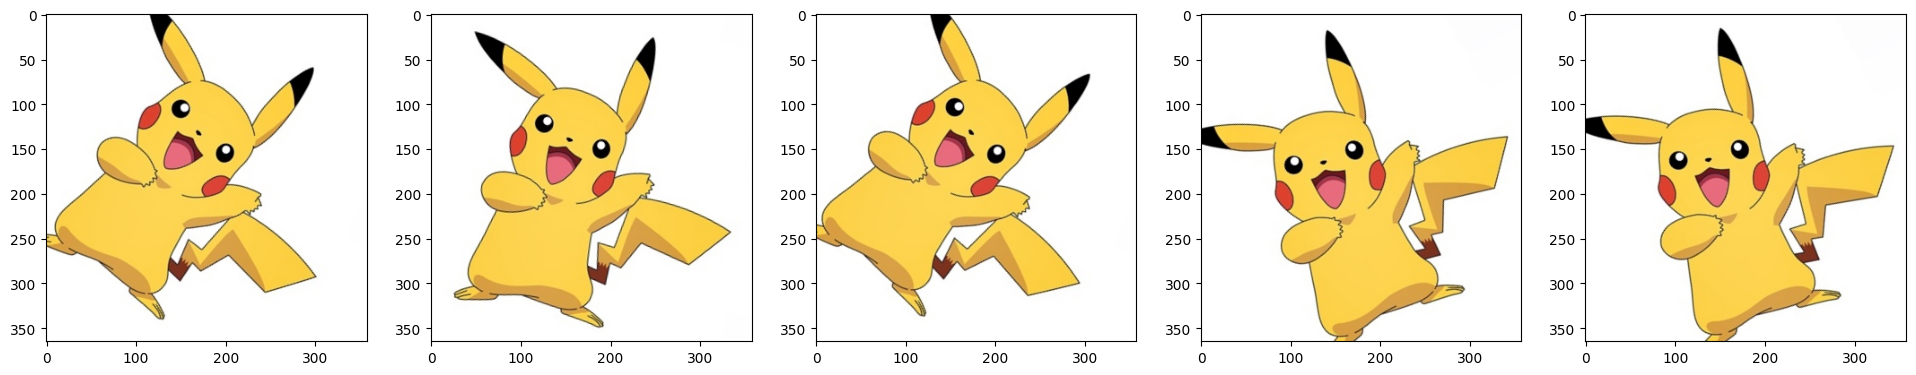

In [ ]:
data_generator = ImageDataGenerator(rotation_range=45)
show_aug_image(image, data_generator, n_images=5)

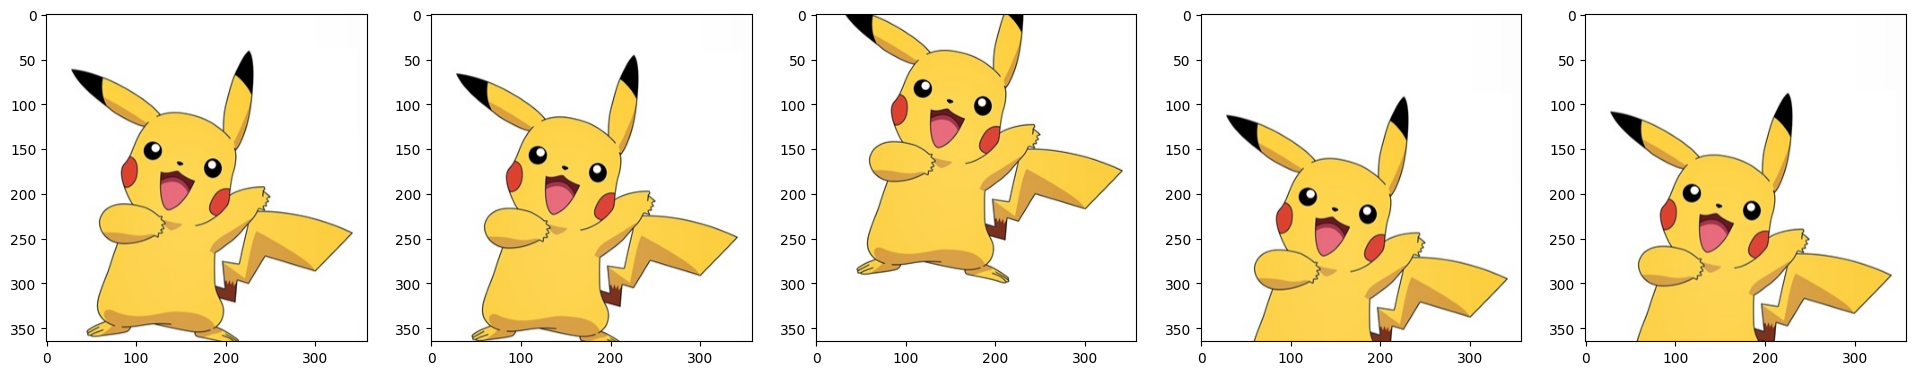

In [ ]:
data_generator = ImageDataGenerator(width_shift_range=0.4, fill_mode='nearest')
show_aug_image(image, data_generator, n_images=5)

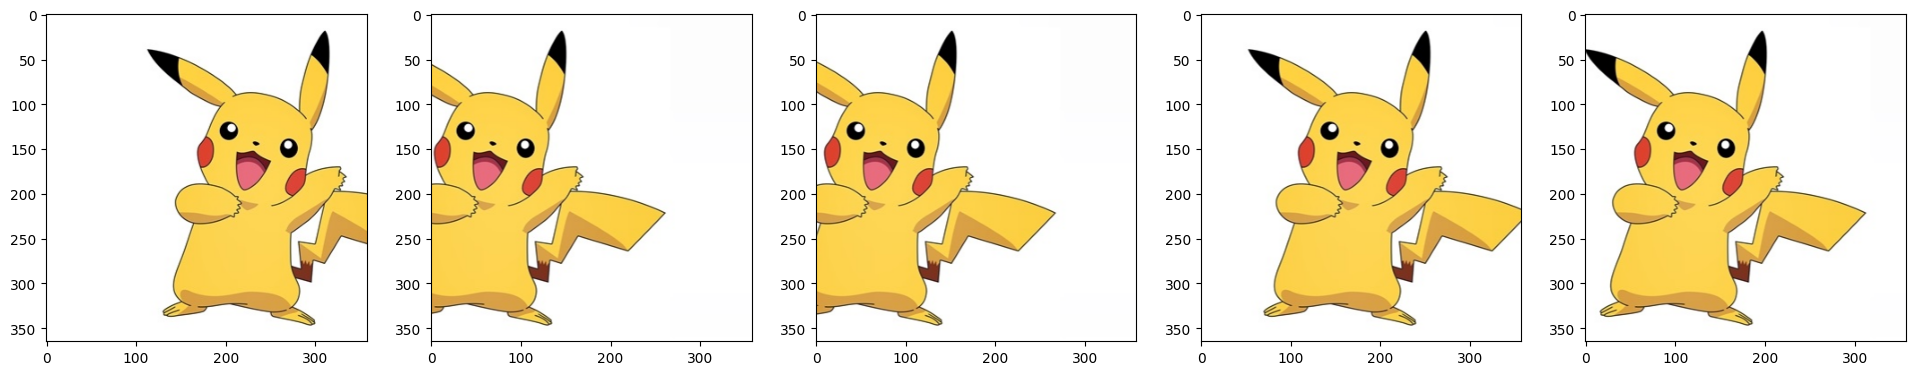

In [ ]:
data_generator = ImageDataGenerator(height_shift_range=0.4, fill_mode='nearest')
show_aug_image(image, data_generator, n_images=5)

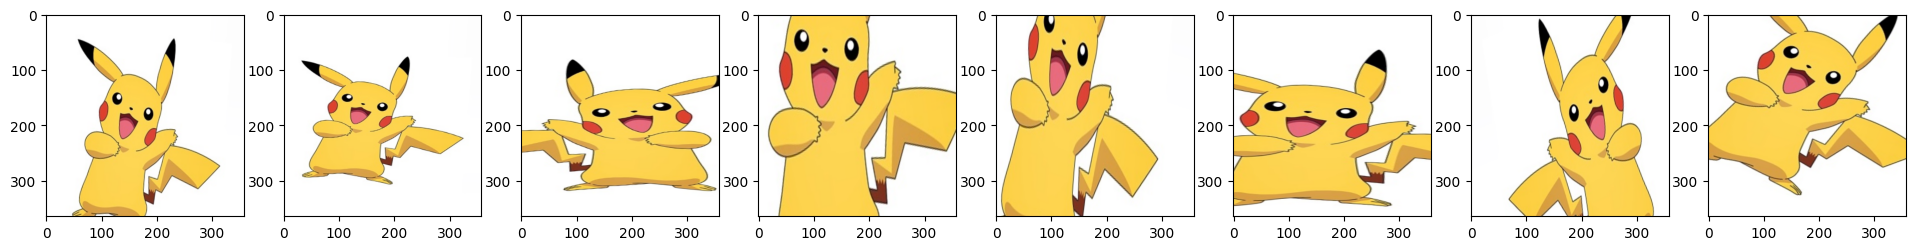

In [ ]:
generator = ImageDataGenerator(
    rotation_range=30,      # 30 범위에서 양방향 임의 회전
    width_shift_range=0.1,  # 10% 범위에서 좌우 임의 이동
    height_shift_range=0.1, # 10% 범위에서 상하 임의 이동
    zoom_range=[0.5,1.5],   # 범위에서 확대 또는 축소
    horizontal_flip=True    # 좌우 반전
)

show_aug_image(image, generator, n_images=8)